Complete the exercises below For **Assignment #5**.

Completed by Klaire Rouse

In this exercise, we are building a logistic regression classification model. We'll work with the [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Load the `tidymodels` library. 

In [1]:
library('tidymodels')


── Attaching packages ────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.13     ✔ recipes      1.3.3 
✔ dials        1.4.4      ✔ rsample      1.3.2 
✔ dplyr        1.2.1      ✔ tailor       0.1.0 
✔ ggplot2      4.0.3      ✔ tidyr        1.3.2 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.6.0      ✔ workflowsets 1.1.1 
✔ purrr        1.2.2      ✔ yardstick    1.4.0 

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()



The data is located in your homework directory in the `diabetes.csv` file. Read in the data by running the following cell. We are "splitting" the data into training and testing sets. We will evaluate our model's performance with the test set.

In [2]:
diabetes = readr::read_csv('diabetes.csv') |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)
diabetes_test = testing(split)

Rows: 768 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, D...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Glimpse the `diabetes_train` table.

In [4]:
glimpse(diabetes_train)


Rows: 576
Columns: 9
$ Pregnancies              <dbl> 1, 1, 4, 1, 3, 8, 1, 5, 5, 10, 11, 3, 7, 7, 7…
$ Glucose                  <dbl> 85, 89, 110, 103, 126, 99, 97, 117, 109, 122,…
$ BloodPressure            <dbl> 66, 66, 92, 30, 88, 84, 66, 92, 75, 78, 76, 6…
$ SkinThickness            <dbl> 29, 23, 0, 38, 41, 0, 15, 0, 26, 31, 0, 25, 0…
$ Insulin                  <dbl> 0, 94, 0, 83, 235, 0, 140, 0, 0, 0, 0, 70, 0,…
$ BMI                      <dbl> 26.6, 28.1, 37.6, 43.3, 39.3, 35.4, 23.2, 34.…
$ DiabetesPedigreeFunction <dbl> 0.351, 0.167, 0.191, 0.183, 0.704, 0.388, 0.4…
$ Age                      <dbl> 31, 21, 30, 33, 27, 50, 22, 38, 60, 45, 35, 2…
$ Outcome                  <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


❓ Which variable is suitable as the "outcome" in a logistic regression model?

**Answer:** The "Outcome" variable is suitable as the "outcome" in the logistic regression model because it is either a 0 for no diabetes or 1 for diabetes.

#link not working for kaggle page below. Added other found descriptions

❓ Navigate to [Kaggle page](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) for this dataset. Find descriptions for the `Glucose` and `BMI` columns. Add these descriptions to the [Markdown table](https://www.markdownguide.org/extended-syntax/#tables) below.

| Column name | Description |
| :---------- | :---------- |
| Glucose     | Glucose concentration in blood |
| BMI         | Body Mass Index |

Make a bar chart showing the frequency of each "outcome" in the `Outcome` column from your `diabetes_train` data.

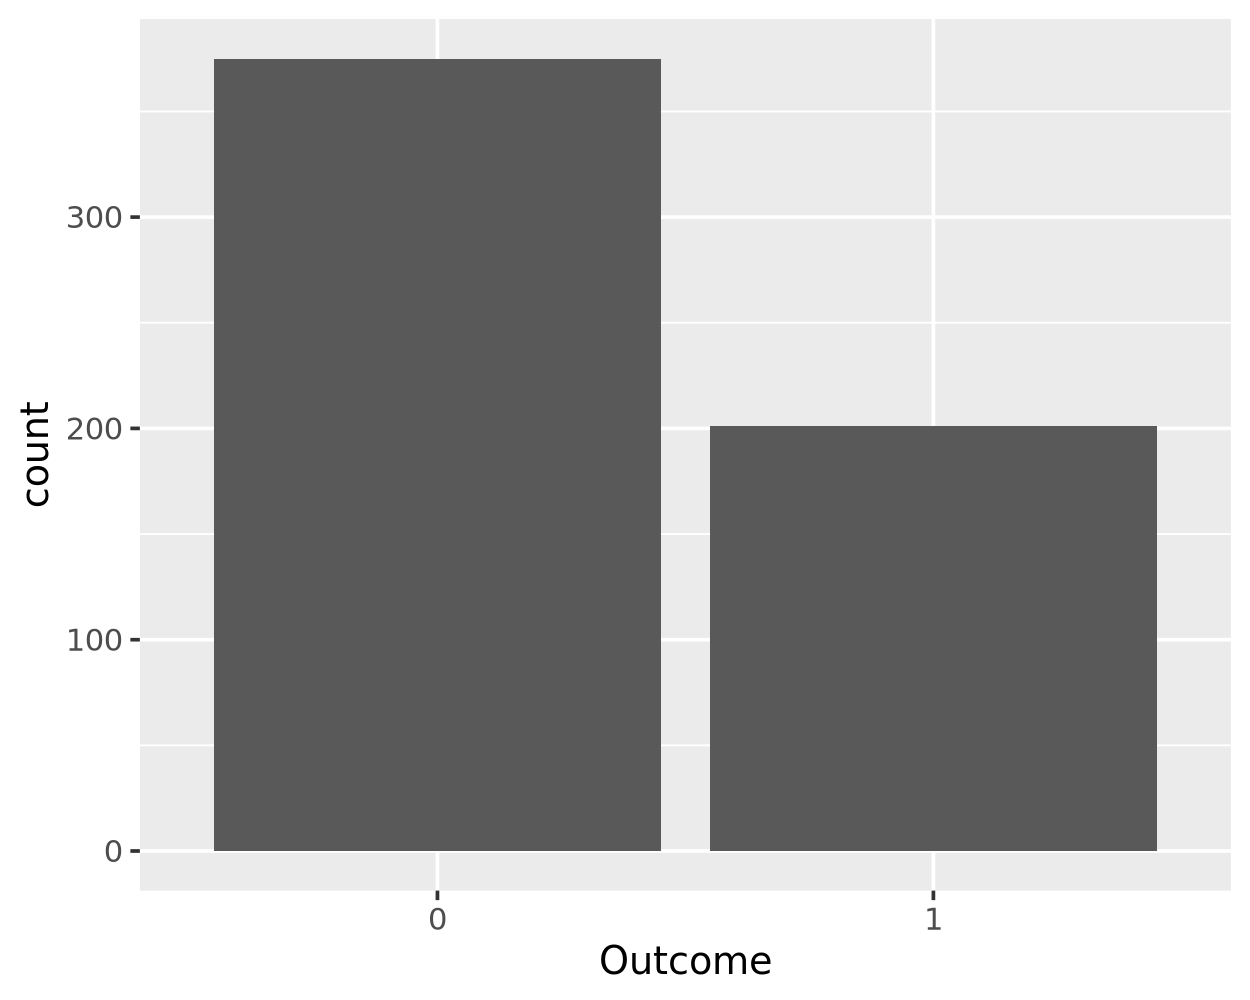

In [5]:
ggplot(
    data = diabetes_train,
    aes(x=Outcome)) +
geom_bar()

❓ Is the data balanced? I.e. do we have equal counts of each outcome?

**Answer:**

We do not have equal counts of each outcome, there are more people without diabetes than with it.



Run the code below to create a table for plotting the predictors we will use in our model: `Glucose` and `BMI`. 

In [7]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI) |>
    pivot_longer(cols = c(Glucose, BMI))

plot_df |> head()

Outcome,name,value
<fct>,<chr>,<dbl>
0,Glucose,85.0
0,BMI,26.6
0,Glucose,89.0
0,BMI,28.1
0,Glucose,110.0
0,BMI,37.6


Using `plot_df`, make a chart showing the relationship of `Glucose` and `BMI` with `Outcome`. 

- use `geom_jitter` for your "geom"
- `facet_wrap` your chart by the `name` variable. (e.g. `facet_wrap(~name, ncol = 2, scales = 'free_x')`)

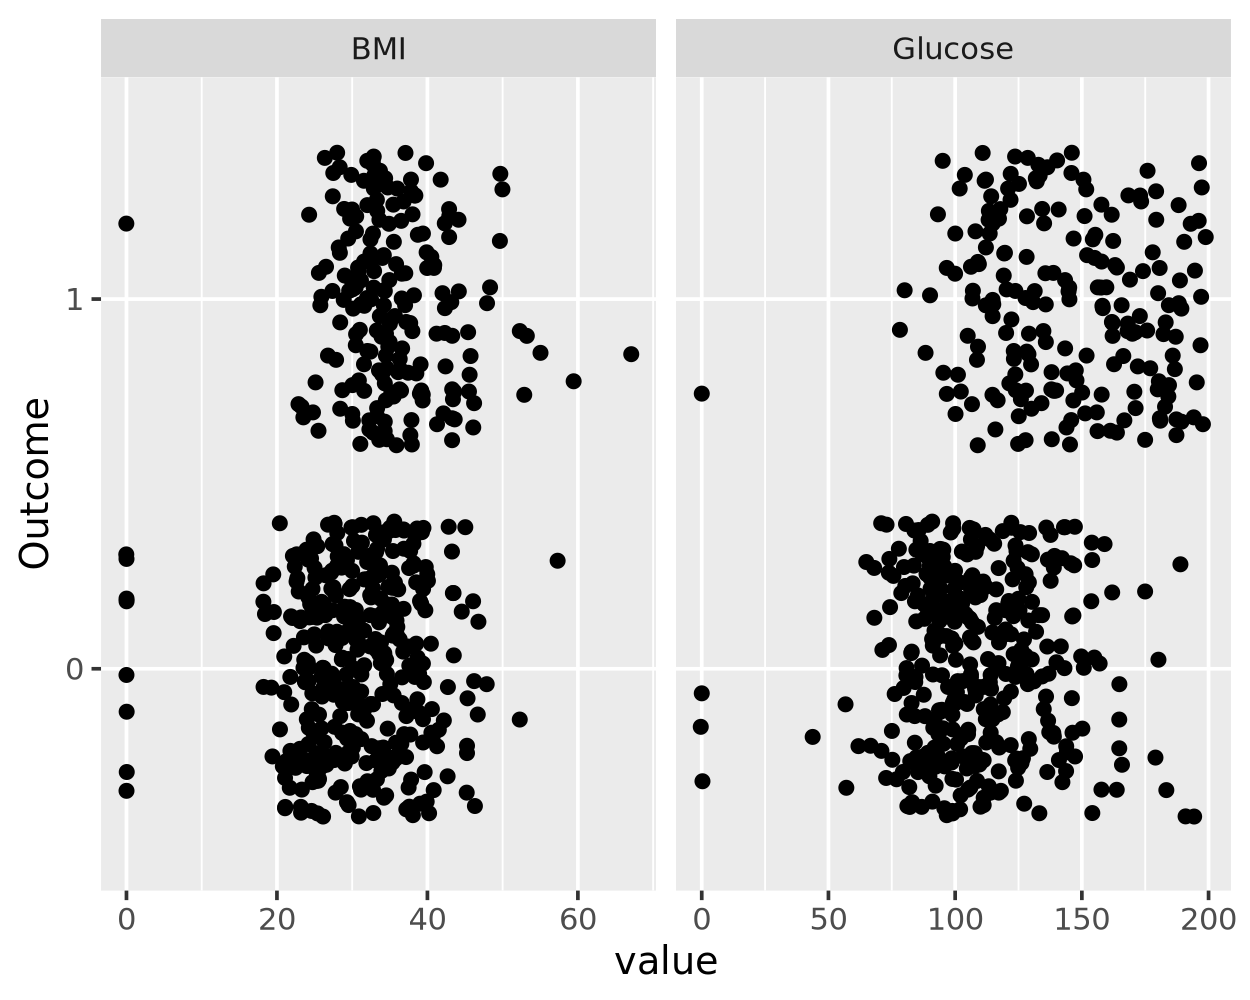

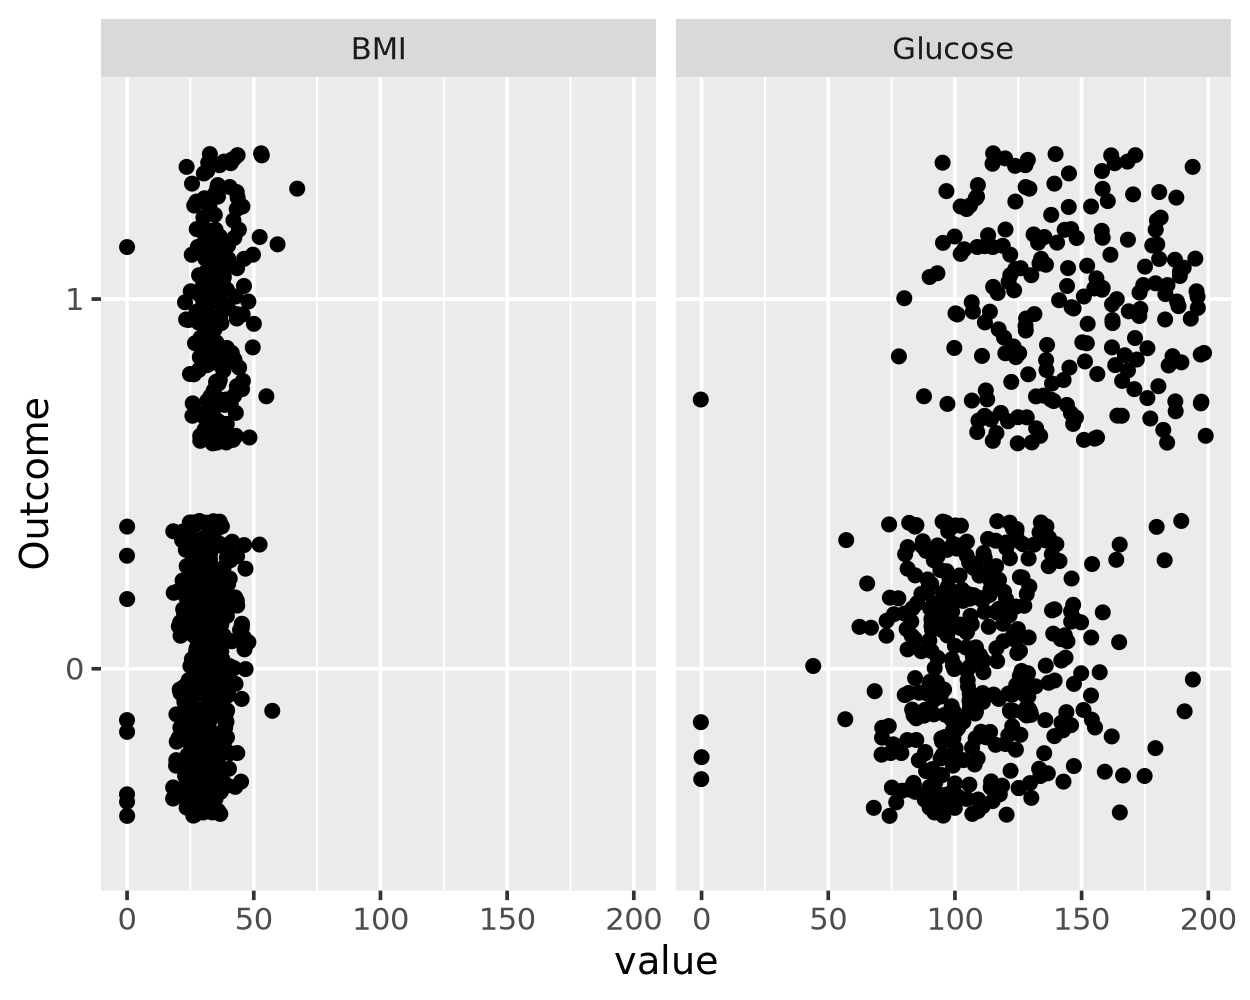

In [14]:
ggplot(
    data = plot_df,
    aes(x=value, y=Outcome))+
    geom_jitter() +
    facet_wrap(~name, ncol=2, scales='free_x')

ggplot(
    data = plot_df,
    aes(x=value, y=Outcome))+
    geom_jitter() +
    facet_wrap(~name, ncol=2)

❓ What happens when you remove the `scales = 'free_x'` argument from the `facet_wrap` function?

**Answer:**

When we remove the scales='free_x' argument form the facet_wrap function, the plots end up on the same horizontal scale, which crams BMI values together since those are typically lower values.

Using your training data, build logistic regression model of `Outcome` with `BMI` and `Glucose` as predictors. 
- Use "glm" for you engine
- The formula for your fit function will be `Outcome ~ BMI + Glucose`

In [15]:
mod = logistic_reg() |> set_engine('glm')


In [17]:
mod_fit = mod |> fit(Outcome ~ BMI + Glucose, data =diabetes_train)
mod_fit

parsnip model object


Call:  stats::glm(formula = Outcome ~ BMI + Glucose, family = stats::binomial, 
    data = data)

Coefficients:
(Intercept)          BMI      Glucose  
   -8.24937      0.07868      0.04008  

Degrees of Freedom: 575 Total (i.e. Null);  573 Residual
Null Deviance:	    745.1 
Residual Deviance: 548.7 	AIC: 554.7

Using `augment` with your fitted model and the `diabetes_test` data as arguments, create a new dataset called `diabetes_test_wPred` that is the `diabetes_test` table including predictions from your model. 

In [19]:
diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test)


Run the code below to generate a confusion matrix for your model predictions. 

(❗️Hint: See Table 4.4 from [*Introduction to Statistical Learning (Version 2)*](https://www.statlearning.com/) for an example confusion matrix.)

In [20]:
diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test)

diabetes_test_wPred |> conf_mat(Outcome, .pred_class)

          Truth
Prediction   0   1
         0 110  33
         1  15  34

❓ Based on the confusion matrix above, 
- How many individuals had diabetes in your test data?
- Of those that actually had diabetes, how many were predicted to have diabetes by your model?
- How many individuals predicted to have diabetes did not have diabetes?

**Answer:** 
1. 67 individuals had diabetes in my test data (33 were not predicted but did, 34 were predicted and did).
2. 34 were predicted to have diabeters by my model.
3. 15 individuals were predicted to have diabetes but did not.